In [6]:
import matplotlib.pyplot as plt 
import pandas as pd
import seaborn

import PIL
from PIL import Image

In [ ]:
image1_p = "/Users/cmbreen/Documents/snow/alaska_dataset/all_images/CP_final_448/CP BA 2/CP BA 2_WSCT0971.JPG"
image2_p = "/Users/cmbreen/Documents/snow/alaska_dataset/all_images/CP_final_448/CP BA 2/CP BA 2_WSCT1223.JPG"
image3_p = "/Users/cmbreen/Documents/snow/alaska_dataset/all_images/CP_final_448/CP BA 2/CP BA 2_WSCT1425.JPG"

image1 = Image.open(image1_p)
image2 = Image.open(image2_p)
image3 = Image.open(image3_p)

predictions = pd.read_csv('/Users/cmbreen/code/snowpoles/models/trained_alaska_cnn_allpoles_camembed_lr1e4/predictions/results.csv')

In [8]:
predictions.head()

,Unnamed: 0,camera_id,filename,datetime,x1_pred,y1_pred,x2_pred,y2_pred,total_length_pixel,snow_depth
0,0,CP MA 12 part fail,CP MA 12 part fail_WSCT0791.JPG,10/28/2022 15:00,216.42451,64.81904,210.67975,395.75714,330.987976,-0.169656
1,1,CP DB 6,CP DB 6_WSCT1110.JPG,05/09/2023 14:00,262.82007,110.40086,265.43112,426.53317,316.143097,-45.457500
2,2,CP DB 15,CP DB 15_WSCT1632.JPG,08/30/2023 14:00,164.33168,160.77322,161.42114,417.13850,256.381775,17.626483
3,3,CP BA 2,CP BA 2_WSCT1391.JPG,05/17/2023 14:00,210.66963,120.59403,209.28020,420.99063,300.399811,2.253051
4,4,CP EA 4 part fail,CP EA 4 part fail_WSCT0517.JPG,10/28/2022 15:00,191.75713,86.13765,192.99179,446.43695,360.301422,-30.782321


In [14]:
image1_kp = predictions[predictions['filename'] == image1_p.split('/')[-1]][['x1_pred', 'y1_pred', 'x2_pred', 'y2_pred']]
image2_kp = predictions[predictions['filename'] == image2_p.split('/')[-1]][['x1_pred', 'y1_pred', 'x2_pred', 'y2_pred']]
image3_kp = predictions[predictions['filename'] == image3_p.split('/')[-1]][['x1_pred', 'y1_pred', 'x2_pred', 'y2_pred']]

In [15]:
image1_kp

,x1_pred,y1_pred,x2_pred,y2_pred
2318,222.94743,124.74523,218.1771,317.76193


(np.float64(-0.5), np.float64(447.5), np.float64(447.5), np.float64(-0.5))

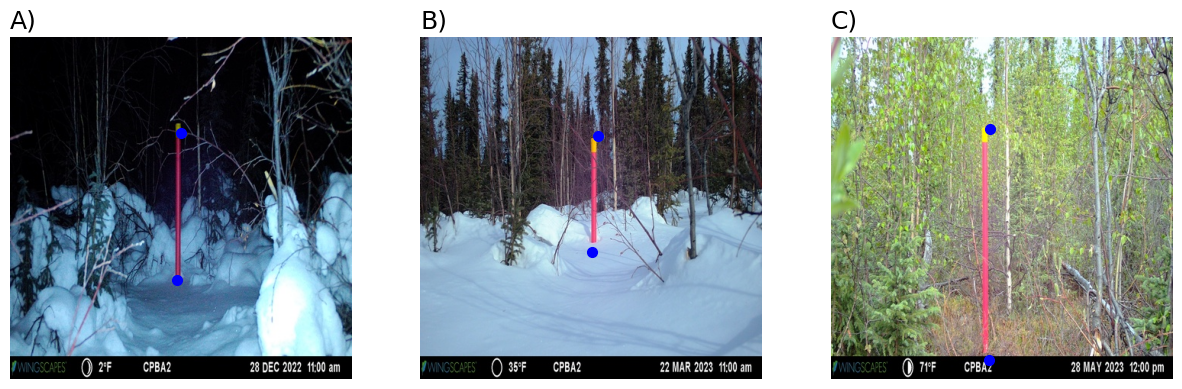

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))  # 1 row, 3 columns

color = 'blue'
marker = '.'
size = 14

# Plot first dataframe on first image
axes[0].imshow(image1)
for idx, row in image1_kp.iterrows():
    axes[0].plot(row['x1_pred'], row['y1_pred'], color = color, marker = marker, markersize=14)  # top keypoint
    axes[0].plot(row['x2_pred'], row['y2_pred'], color = color, marker = marker, markersize=14)  # bottom keypoint
axes[0].set_title('A)', loc = 'left', size=18)
axes[0].axis('off')  # Optional: remove axes

# Plot second dataframe on second image
axes[1].imshow(image2)
for idx, row in image2_kp.iterrows():
    axes[1].plot(row['x1_pred'], row['y1_pred'], color = color, marker = marker, markersize=14)  # top keypoint
    axes[1].plot(row['x2_pred'], row['y2_pred'], color = color, marker = marker, markersize=14)  # bottom keypoint
axes[1].set_title('B)', loc = 'left', size= 18)
axes[1].axis('off')

# Plot third dataframe on third image
axes[2].imshow(image3)
for idx, row in image3_kp.iterrows():
    axes[2].plot(row['x1_pred'], row['y1_pred'], color = color, marker = marker, markersize=14)  # top keypoint
    axes[2].plot(row['x2_pred'], row['y2_pred'], color = color, marker = marker, markersize=14)  # bottom keypoint
axes[2].set_title('C)', loc = 'left', size = 18)
axes[2].axis('off')
